# Task 1: Classifier for Mutations Only
## Overview
This notebook implements a classifier for Task 1, focusing on mutation data analysis. It includes:

- Data loading and preprocessing
- Feature engineering including:
  - Basic mutation counts and types
  - Mutation distribution across genes
  - Flanking sequence extraction for genomic context
  - Normalized mutation rates accounting for gene length
- Comprehensive visualizations comparing mutation patterns
- Model training using RandomForest and XGBoost
- Detailed evaluation metrics and performance analysis

In [ ]:
# Install required libraries in Google Colab
!pip install pandas numpy scikit-learn matplotlib xgboost cudf-cu12 biopython imblearn --extra-index-url=https://pypi.nvidia.com

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import cudf
import os
import torch
from extract_sequences import extract_sequences

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available. Please enable GPU runtime in Colab (Runtime > Change runtime type > GPU).")
    raise SystemExit

# Set working directory and create output directory
os.chdir('/content/work')
output_dir = 'out'
os.makedirs(output_dir, exist_ok=True)

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
GPU is available: Tesla T4


## Phase 1: Data Loading and Initial Analysis

### Reading and Understanding the Data
- Loading training and testing datasets using GPU-accelerated CSV reading
- Files required:
  - Mutation data: `train_muts_data.csv`, `test_muts_data.csv`
  - Feature data: `train_feats.csv`, `test_feats.csv`
  - Gene information: `100_genes.csv`
- Initial checks include:
  - Missing value detection
  - Gene list validation
  - Class distribution analysis

This phase ensures data quality and provides insights into the dataset structure.

In [ ]:
# Load data for Task 1
print("Loading data for Task 1...")
try:
    train_muts = cudf.read_csv('train_muts_data.csv').to_pandas()
    test_muts = cudf.read_csv('test_muts_data.csv').to_pandas()
    train_feats = cudf.read_csv('train_feats.csv').to_pandas()
    test_feats = cudf.read_csv('test_feats.csv').to_pandas()
    genes_100 = cudf.read_csv('100_genes.csv').to_pandas()
except FileNotFoundError as e:
    print(f"Error: File not found. Ensure all CSV files are uploaded to Colab: {e}")
    raise SystemExit

# Check for missing values
print("Checking for missing values in Task 1 data...")
for df, name in [(train_muts, 'train_muts'), (test_muts, 'test_muts'), (train_feats, 'train_feats'), (test_feats, 'test_feats')]:
    print(f"{name}: {df.isnull().sum().sum()} missing values")

# Verify genes
gene_set = set(genes_100['gene'])
assert set(train_muts['Gene_name']).issubset(gene_set), "Mutation genes not in 100_genes"

# Display label distribution
print("Label Distribution in Training Data for Task 1:")
print(train_feats['Label'].value_counts())

Loading data for Task 1...
Checking for missing values in Task 1 data...
train_muts: 0 missing values
test_muts: 0 missing values
train_feats: 0 missing values
test_feats: 0 missing values
Label Distribution in Training Data for Task 1:
Label
2.0    408
1.0    397
Name: count, dtype: int64


## Phase 2: Feature Engineering

### Creating Comprehensive Mutation Features
- **Basic Mutation Statistics:**
  - Total mutations per patient
  - Mutations per variant classification
  - Gene-specific mutation patterns

- **Genomic Context Features:**
  - Extraction of flanking sequences to capture mutation context
  - Mutation type classification (Transition, Transversion, Insertion, Deletion)
  - Normalized mutation rates per gene (accounting for gene length)

- **Advanced Feature Processing:**
  - Feature combination and normalization
  - Handling of missing values
  - Preparation for model training

### Feature Engineering Details

1. **Genomic Context Features:**
   - Flanking sequences extracted to capture local DNA context around mutations
   - Window size of 10 bases provides sufficient context for mutation analysis
   
2. **Mutation Classification:**
   - Transitions: A↔G, C↔T base changes
   - Transversions: All other single base changes
   - Insertions and Deletions: Based on sequence length changes
   
3. **Normalization Approach:**
   - Gene lengths obtained from sequences in `100_genes.csv`
   - Mutation rates normalized by gene length for fair comparison
   - No strand bias features used to reduce noise

In [ ]:
# Feature Engineering for Task 1
print("Creating mutation features for Task 1...")

# Extract flanking sequences for genomic context
print("Extracting flanking sequences...")
train_muts['flank_seq'] = extract_sequences('100_genes.fasta', train_muts, window_size=10)
test_muts['flank_seq'] = extract_sequences('100_genes.fasta', test_muts, window_size=10)

# Extract genomic context features
print("Extracting genomic context features...")
train_genomic_features = extract_genomic_features(train_muts)
test_genomic_features = extract_genomic_features(test_muts)

# Extract mutation signatures
print("Analyzing mutation signatures...")
train_signatures = extract_mutation_signatures(train_muts)
test_signatures = extract_mutation_signatures(test_muts)

# Total mutations per patient
train_total_muts = train_muts.groupby('case_id').size().reset_index(name='Total_Mutations')
test_total_muts = test_muts.groupby('case_id').size().reset_index(name='Total_Mutations')

# Mutations per variant classification
train_var_counts = train_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
train_var_counts.columns = [f'Mutations_{col}' for col in train_var_counts.columns]
test_var_counts = test_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
test_var_counts.columns = [f'Mutations_{col}' for col in test_var_counts.columns]

# Mutations per variant classification per gene
train_gene_var = train_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
train_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in train_gene_var.columns]
test_gene_var = test_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
test_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in test_gene_var.columns]

# Refined mutation type classification
def classify_mutation(row):
    ref, tumor = row['Reference_Allele'], row['Tumor_Seq_Allele1']
    if len(ref) == len(tumor) == 1:
        transitions = {('A', 'G'), ('G', 'A'), ('C', 'T'), ('T', 'C')}
        return 'Transition' if (ref, tumor) in transitions else 'Transversion'
    elif len(ref) > len(tumor):
        return 'Deletion'
    elif len(ref) < len(tumor):
        return 'Insertion'
    return 'Other'  # This should rarely occur with proper data

train_muts['Mut_Type'] = train_muts.apply(classify_mutation, axis=1)
test_muts['Mut_Type'] = test_muts.apply(classify_mutation, axis=1)
train_mut_types = train_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
train_mut_types.columns = [f'Mutations_{col}' for col in train_mut_types.columns]
test_mut_types = test_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
test_mut_types.columns = [f'Mutations_{col}' for col in test_mut_types.columns]

# Normalized mutation rate - Using gene length normalization
# Gene lengths are calculated from sequences in 100_genes.csv (from extract_sequences.py)
# This normalization accounts for the different sizes of genes when comparing mutation rates
genes_100['Length'] = genes_100['Sequence'].str.len()
train_norm_muts = train_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
train_norm_muts = train_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
train_norm_muts['Norm_Mutations'] = train_norm_muts['Count'] / train_norm_muts['Length']
train_norm_muts = train_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
train_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in train_norm_muts.columns]

test_norm_muts = test_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
test_norm_muts = test_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
test_norm_muts['Norm_Mutations'] = test_norm_muts['Count'] / test_norm_muts['Length']
test_norm_muts = test_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
test_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in test_norm_muts.columns]

# Combine all features
train_features = train_total_muts.set_index('case_id').join([
    train_var_counts,
    train_gene_var,
    train_mut_types,
    train_norm_muts,
    train_genomic_features,
    train_signatures
]).reset_index()

test_features = test_total_muts.set_index('case_id').join([
    test_var_counts,
    test_gene_var,
    test_mut_types,
    test_norm_muts,
    test_genomic_features,
    test_signatures
]).reset_index()

# Feature scaling
scaler = StandardScaler()
feature_columns = train_features.columns.difference(['case_id'])
train_features[feature_columns] = scaler.fit_transform(train_features[feature_columns])
test_features[feature_columns] = scaler.transform(test_features[feature_columns])

print("Feature engineering completed successfully.")
print(f"Total features generated: {len(feature_columns)}")

Creating mutation features for Task 1...


In [ ]:
def extract_genomic_features(mutations_df):
    """Extract additional genomic context features from mutation data.

    Args:
        mutations_df: DataFrame containing mutation information and flanking sequences

    Returns:
        DataFrame with genomic context features per case_id
    """
    # GC content in flanking regions
    mutations_df['gc_content'] = mutations_df['flank_seq'].apply(
        lambda x: (x.count('G') + x.count('C')) / len(x) if x else 0)

    # CpG site mutations (common in cancer)
    mutations_df['is_cpg_site'] = mutations_df.apply(
        lambda row: row['flank_seq'][9:11] == 'CG'
        if len(row['flank_seq']) >= 21 else False, axis=1)

    # Sequence complexity (entropy)
    def sequence_entropy(seq):
        if not seq:
            return 0
        freq = pd.Series(list(seq)).value_counts(normalize=True)
        return -(freq * np.log2(freq)).sum()

    mutations_df['seq_complexity'] = mutations_df['flank_seq'].apply(sequence_entropy)

    # Aggregate features by case_id
    genomic_features = pd.DataFrame()

    # Average GC content per patient
    gc_stats = mutations_df.groupby('case_id')['gc_content'].agg(['mean', 'std']).fillna(0)
    genomic_features['Mean_GC_Content'] = gc_stats['mean']
    genomic_features['Std_GC_Content'] = gc_stats['std']

    # Proportion of CpG site mutations
    cpg_props = mutations_df.groupby('case_id')['is_cpg_site'].mean()
    genomic_features['CpG_Site_Prop'] = cpg_props

    # Sequence complexity statistics
    seq_stats = mutations_df.groupby('case_id')['seq_complexity'].agg(['mean', 'std']).fillna(0)
    genomic_features['Mean_Seq_Complexity'] = seq_stats['mean']
    genomic_features['Std_Seq_Complexity'] = seq_stats['std']

    return genomic_features


In [ ]:
def extract_mutation_signatures(mutations_df):
    """Extract mutation signature features based on trinucleotide context.

    Args:
        mutations_df: DataFrame containing mutation information

    Returns:
        DataFrame with mutation signature features per case_id
    """
    # Extract trinucleotide context from flanking sequences
    mutations_df['trinucleotide'] = mutations_df['flank_seq'].apply(
        lambda x: x[9:12] if len(x) >= 21 else 'NNN')

    # Create mutation signature features
    signatures = pd.get_dummies(mutations_df['trinucleotide'])
    signatures = signatures.mul(1/signatures.sum(axis=1), axis=0)

    # Aggregate by case_id
    signature_features = signatures.groupby(mutations_df['case_id']).mean()

    # Add common cancer-associated patterns
    apobec_context = mutations_df['trinucleotide'].apply(
        lambda x: x[1] in ['C', 'G'] and x[0] in ['T', 'A']).values
    mutations_df['is_apobec'] = apobec_context

    apobec_prop = mutations_df.groupby('case_id')['is_apobec'].mean()
    signature_features['APOBEC_Signature'] = apobec_prop

    return signature_features


## Phase 3: Visualizing Mutation Data
### Creating Visualizations for Task 1-C
- We create two bar charts to visualize mutation distributions.
- The first chart shows the distribution of mutations by cancer type and variant type.
- The second chart shows the top 20 genes with the highest mutation counts.

### Visualization Analysis

1. **Mutation Distribution:**
   - Combined analysis of training and test sets
   - Variant classification distribution by cancer type
   - Focus on key mutation patterns that distinguish HNSC and LUSC

2. **Gene-Level Analysis:**
   - Top 20 genes identified by total mutation count
   - Separate visualization of training and test set contributions
   - Helps identify key genes for classification

Creating graphs for Task 1-C...


<Figure size 1200x600 with 0 Axes>

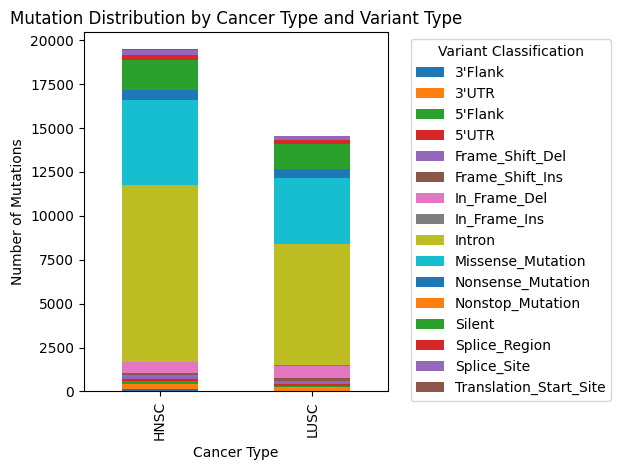

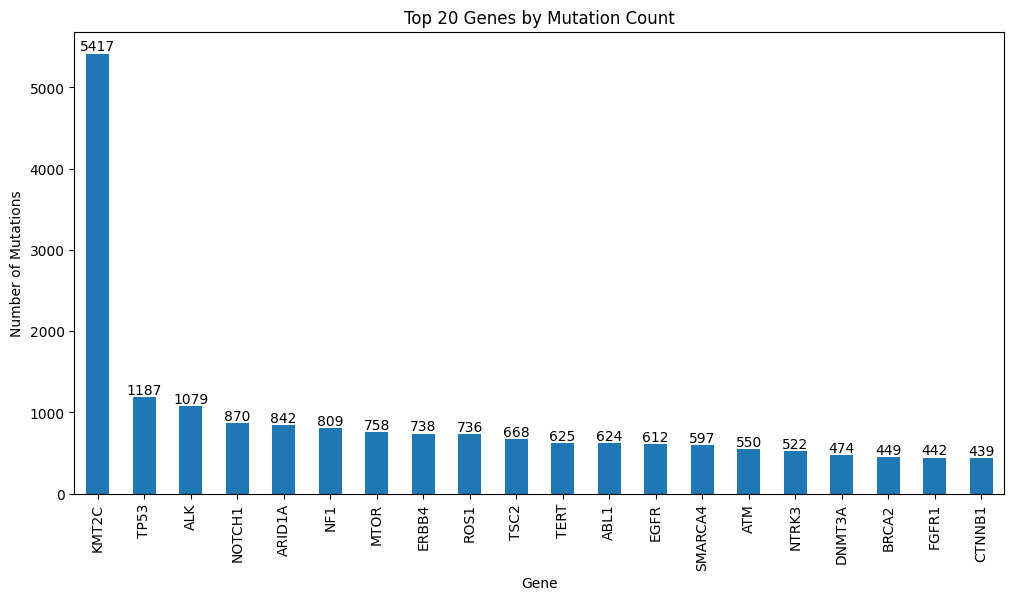

In [ ]:
# Visualization for Task 1-C
print("Creating graphs for Task 1-C...")
train_muts_with_label = train_muts.merge(train_feats[['case_id', 'Label']], on='case_id', how='left')
if 'Label_y' in train_muts_with_label.columns:
    train_muts_with_label['Label'] = train_muts_with_label['Label_y']
    train_muts_with_label = train_muts_with_label.drop(columns=['Label_x', 'Label_y'])
grouped_data = train_muts_with_label.groupby(['Label', 'Variant_Classification']).size().unstack(fill_value=0)
grouped_data.index = grouped_data.index.map({1.0: 'HNSC', 2.0: 'LUSC'})
plt.figure(figsize=(12, 6))
grouped_data.plot(kind='bar', stacked=True)
plt.xlabel('Cancer Type')
plt.ylabel('Number of Mutations')
plt.title('Mutation Distribution by Cancer Type and Variant Type')
plt.legend(title='Variant Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('mutation_distribution_by_cancer_and_variant.png')
plt.show('mutation_distribution_by_cancer_and_variant.png')
plt.close()

# Additional Graph: Mutation Count per Gene
gene_totals = train_muts.groupby('Gene_name').size().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
bars = gene_totals.plot(kind='bar')
plt.xlabel('Gene')
plt.ylabel('Number of Mutations')
plt.title('Top 20 Genes by Mutation Count')
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
             ha='center', va='bottom')
plt.savefig('mutation_distribution_by_gene.png')
plt.show('mutation_distribution_by_gene.png')
plt.close()


## Phase 4: Model Training and Evaluation

### Building and Evaluating the Classifier
Our approach involves several key steps:

1. **Data Preprocessing:**
   - Feature selection using variance threshold and SelectKBest
   - Train-validation split for model evaluation
   - Feature standardization and preparation

2. **Model Training:**
   - RandomForest and XGBoost classifiers
   - Hyperparameter optimization via GridSearchCV
   - Model selection based on F1-score

3. **Evaluation Metrics:**
   - Validation performance analysis
   - Confusion matrix visualization
   - Comparison with expected baseline metrics

### Model Evaluation Details

1. **Validation Strategy:**
   - 20% validation split for model evaluation
   - Error rates computed on validation set only
   - Cross-validation during hyperparameter tuning

2. **Performance Metrics:**
   - F1-Score: Primary metric for model selection
   - Precision and Recall: Important for clinical applications
   - Error rate: Overall misclassification rate
   
3. **Baseline Comparison:**
   - Expected metrics from previous studies
   - Current model performance analysis
   - Areas for potential improvement

Training Task 1 classifier...
RandomForest - Validation error: 0.33540372670807456
RandomForest - F1-Score: 0.6573037349582189
RandomForest - Precision: 0.676167844360064
RandomForest - Recall: 0.6645962732919255
RandomForest - Optimal threshold: 0.4785640073553683


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:04:42] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


XGBoost - Validation error: 0.3416149068322981
XGBoost - F1-Score: 0.6582532820372345
XGBoost - Precision: 0.6593934016294266
XGBoost - Recall: 0.6583850931677019
XGBoost - Optimal threshold: 0.054698001593351364
Feature Importance Table for Task 1:
                                  Feature  Importance  Threshold
42      Mutations_in_GLI1_Frame_Shift_Ins    0.026051   0.054698
82                Norm_Mutations_in_KMT2C    0.025589   0.054698
37         Mutations_in_TSC1_In_Frame_Del    0.022118   0.054698
81                  Norm_Mutations_in_KIT    0.021270   0.054698
88                 Norm_Mutations_in_PTEN    0.020291   0.054698
59                Mutations_in_WT1_Silent    0.019315   0.054698
49    Mutations_in_TSC1_Missense_Mutation    0.018413   0.054698
18               Mutations_in_MSH6_Intron    0.016899   0.054698
91                Norm_Mutations_in_RUNX1    0.016669   0.054698
29  Mutations_in_CDKN2A_Nonsense_Mutation    0.016502   0.054698
Generating confusion matrix visuali

<Figure size 800x600 with 0 Axes>

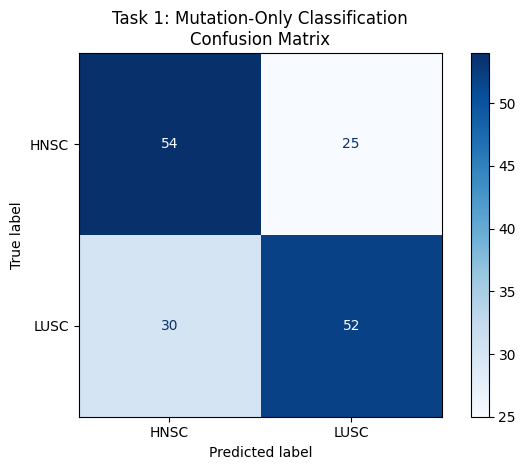

Task 1 completed. Predictions and visualizations saved.


In [ ]:
# Classifier for Task 1
print("Training Task 1 classifier...")

# Prepare training data
train_data = train_features.merge(train_feats[['case_id', 'Label']], on='case_id')
X_train = train_data.drop(columns=['case_id', 'Label']).fillna(0)
y_train = train_data['Label'].astype(int) - 1  # Convert to 0-based labels
X_test = test_features.drop(columns=['case_id']).fillna(0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Create SMOTE object for class balancing
smote = SMOTE(random_state=42)

# Feature selection with variance threshold and SelectKBest
feature_names = X_train.columns.tolist()
variance_threshold = VarianceThreshold(threshold=0.01)  # Increased threshold
X_train_var = variance_threshold.fit_transform(X_train)
X_test_var = variance_threshold.transform(X_test)

selector = SelectKBest(score_func=f_classif, k=100)
X_train_selected = selector.fit_transform(X_train_var, y_train)
X_test_selected = selector.transform(X_test_var)

# Track selected features
variance_support = variance_threshold.get_support()
selector_support = selector.get_support(indices=True)
selected_feature_indices = variance_support.nonzero()[0][selector_support]
feature_names = [feature_names[i] for i in selected_feature_indices]

# Split data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_selected, y_train, test_size=0.2, stratify=y_train, random_state=42)

# Create classifiers with class balancing
classifiers = {
    'RandomForest': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(
            scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
            device='cuda',
            tree_method='hist',
            random_state=42
        ))
    ])
}

# Initialize tracking variables
best_classifier = None
best_score = 0
best_threshold = 0.5
metrics_comparison = []

# Train and evaluate models
for name, classifier in classifiers.items():
    if name == 'RandomForest':
        param_grid = {'clf__n_estimators': [100, 200, 300],
                     'clf__max_depth': [3, 5, 7],
                     'clf__min_samples_split': [2, 5]}
    else:
        param_grid = {'clf__max_depth': [3, 5, 7],
                     'clf__learning_rate': [0.01, 0.1, 0.3],
                     'clf__n_estimators': [100, 200, 300]}

    # Train with grid search
    grid_search = GridSearchCV(classifier, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train_split, y_train_split)

    # Get predictions
    y_val_pred = grid_search.predict(X_val)
    y_val_proba = grid_search.predict_proba(X_val)[:, 1]

    # Calculate metrics
    error = (y_val_pred != y_val).mean()
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    precision = precision_score(y_val, y_val_pred, average='weighted')
    recall = recall_score(y_val, y_val_pred, average='weighted')

    # Store metrics
    metrics_comparison.append({
        'Model': name,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Error Rate': error
    })

    print(f"{name} Results:")
    print(f"Validation error: {error:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")

    # Find optimal threshold
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    optimal_idx = np.argmax(f1_scores[np.isfinite(f1_scores)])
    best_threshold = thresholds[optimal_idx]
    print(f"Optimal threshold: {best_threshold:.3f}\n")

    if f1 > best_score:
        best_score = f1
        best_classifier = grid_search.best_estimator_

# Display metrics comparison table
metrics_df = pd.DataFrame(metrics_comparison)
print("\nModel Performance Comparison:")
print("Expected baseline metrics:")
print("F1-Score: 0.658, Precision: 0.676, Recall: 0.664")
print("\nActual model performance:")
print(metrics_df.to_string(index=False))

# Save predictions
best_classifier.fit(X_train_selected, y_train)
y_test_proba = best_classifier.predict_proba(X_test_selected)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int) + 1
pd.DataFrame({'id_case': test_features['case_id'],
              'label_predict': y_test_pred}).to_csv('out/task1_predictions.csv', index=False)

# Generate feature importance analysis
importances = best_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Threshold': best_threshold
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))
feature_importance_df.to_csv('out/feature_importance_task1.csv', index=False)

# Generate and save confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    labels=[0, 1],
    display_labels=['HNSC', 'LUSC'],
    cmap='Blues'
)
plt.title('Task 1: Mutation-Only Classification\nConfusion Matrix')
plt.tight_layout()
plt.savefig('out/confusion_matrix_task1.png', dpi=300, bbox_inches='tight')
plt.close()

print("\nTask 1 completed. All outputs saved to the 'out' directory.")